# EX 6: Medical Insurance Prediction (Part 2)

**Learning objectives:**
- Solve a polynomial regression problem
- Implement and compare regularization methods (Ridge, Lasso, Elastic Net)

**Part 1**
- Load the dataset: insurance.csv
- Use findings from EX5 to improve your best regression model
- Add polynomial components and retrain
- Implement Ridge, Lasso, and Elastic Net and compare results

**Part 2**
- Write a summary of findings (what improved, what didn’t, and which model you’d pick).


## Collecting data
Load the dataset and confirm basic structure (same idea as EX5).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("insurance-2.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


##EDA
- Distribution of charges
- Charges vs key numeric predictors

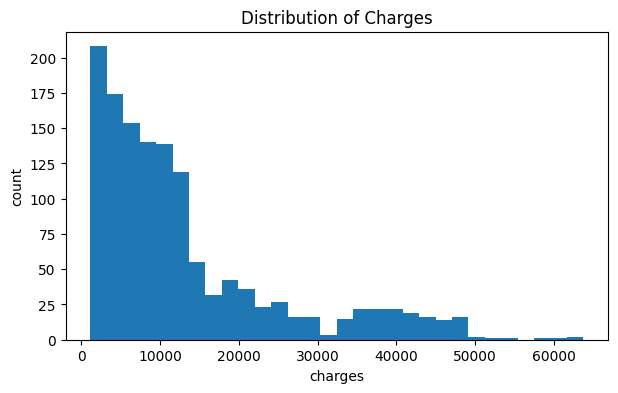

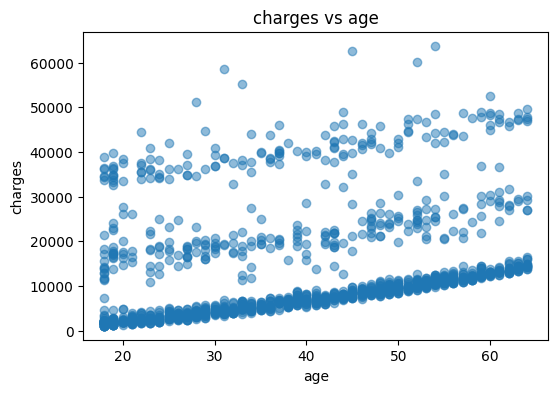

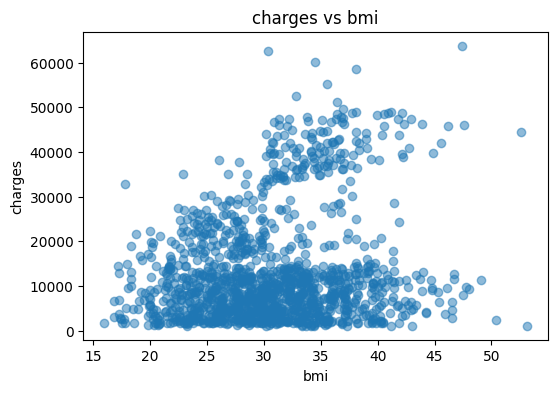

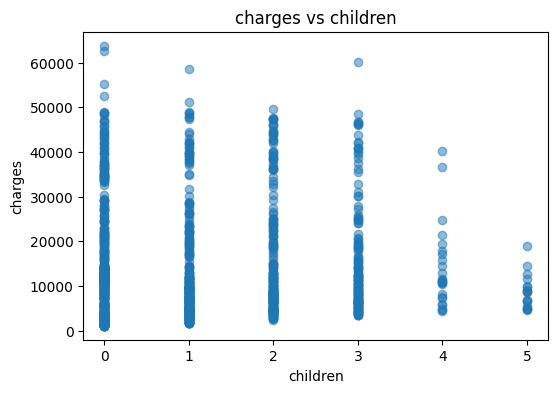

In [3]:
plt.figure(figsize=(7,4))
plt.hist(df["charges"], bins=30)
plt.title("Distribution of Charges")
plt.xlabel("charges")
plt.ylabel("count")
plt.show()

for col in ["age", "bmi", "children"]:
    plt.figure(figsize=(6,4))
    plt.scatter(df[col], df["charges"], alpha=0.5)
    plt.title(f"charges vs {col}")
    plt.xlabel(col)
    plt.ylabel("charges")
    plt.show()


## Train-test split

In [4]:
X = df.drop(columns=["charges"])
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((1070, 6), (268, 6))

## Preprocessing
- Numeric: Standardize (important for SGD/regularization)
- Categorical: One-hot encode (dummy coding)
We use a pipeline so the steps are consistent across all models.


In [5]:
num_cols = ["age", "bmi", "children"]
cat_cols = ["sex", "smoker", "region"]

preprocess_basic = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

## Baseline model (reference point)
- One-hot encoding for categoricals
- Scaling numeric predictors
compare all improved models against this baseline.

In [6]:
baseline = Pipeline([
    ("preprocess", preprocess_basic),
    ("model", LinearRegression())
])

baseline.fit(X_train, y_train)
pred_base = baseline.predict(X_test)

mae_base  = mean_absolute_error(y_test, pred_base)
rmse_base = np.sqrt(mean_squared_error(y_test, pred_base))
r2_base   = r2_score(y_test, pred_base)

print("Baseline Linear Regression")
print("MAE :", round(mae_base, 2))
print("RMSE:", round(rmse_base, 2))
print("R2:", round(r2_base, 4))

Baseline Linear Regression
MAE : 4181.19
RMSE: 5796.28
R2: 0.7836


## Polynomial regression (numeric features)
We add polynomial terms to numeric variables (age, bmi, children) to capture non-linear patterns.
We do NOT polynomial-expand one-hot categorical columns.
We test degree 2 and degree 3.

In [7]:
preprocess_poly2 = ColumnTransformer([
    ("num", Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False))
    ]), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

poly2_model = Pipeline([
    ("preprocess", preprocess_poly2),
    ("model", LinearRegression())
])

poly2_model.fit(X_train, y_train)
pred_poly2 = poly2_model.predict(X_test)

print("Poly Degree 2 and LinearRegression")
print("MAE :", round(mean_absolute_error(y_test, pred_poly2), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_poly2)), 2))
print("R2  :", round(r2_score(y_test, pred_poly2), 4))

Poly Degree 2 and LinearRegression
MAE : 4254.27
RMSE: 5841.28
R2  : 0.7802


In [8]:
preprocess_poly3 = ColumnTransformer([
    ("num", Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=3, include_bias=False))
    ]), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
])

poly3_model = Pipeline([
    ("preprocess", preprocess_poly3),
    ("model", LinearRegression())
])

poly3_model.fit(X_train, y_train)
pred_poly3 = poly3_model.predict(X_test)

print("Poly Degree 3 and LinearRegression")
print("MAE :", round(mean_absolute_error(y_test, pred_poly3), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_poly3)), 2))
print("R2  :", round(r2_score(y_test, pred_poly3), 4))

Poly Degree 3 and LinearRegression
MAE : 4199.49
RMSE: 5879.68
R2  : 0.7773


## Regularization
- Ridge (L2): shrinks coefficients smoothly, helps with multicollinearity
- Lasso (L1): can shrink some coefficients to 0 (feature selection)
- Elastic Net: mix of L1 and L2
apply them on the polynomial degree 2 feature set and use CV to choose hyperparameters.

In [9]:
# Ridge
alphas = np.logspace(-3, 4, 80)

ridge_model = Pipeline([
    ("preprocess", preprocess_poly2),
    ("model", RidgeCV(alphas=alphas))
])

ridge_model.fit(X_train, y_train)
pred_ridge = ridge_model.predict(X_test)
ridge_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 RidgeCV(alphas=array([1.00000000e-03, 1.22633068e-03, 1.50388695e...
       9.16273901e+01, 1.12365480e+02, 1.37797236e+02, 1.68984979e+02,
       2.07231465e+02, 2.54134304e+02, 3.11652694e+02, 3.82189262e+02,
       4.68690419e+02, 5.74769442e+02, 7.04857404e+02, 8.64388262e+02,
       1.06002585e+03, 1.29994222e+03, 1.59415904e+03, 1.95496614e+03,
       2.39743497e+03, 2.94004806e+03, 3.60547115e+03, 4.42149991e+03,
       5.42222101e+03, 6.64943600e+03, 8.15440740e+03, 1.00000000e+04])))])

In [10]:
print("Poly2 and RidgeCV")
print("alpha:", ridge_model.named_steps["model"].alpha_)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_ridge)), 2))
print("R2  :", round(r2_score(y_test, pred_ridge), 4))

Poly2 and RidgeCV
alpha: 0.5582586268862695
RMSE: 5843.75
R2  : 0.78


In [11]:
# LassoCV
lasso_model = Pipeline([
    ("preprocess", preprocess_poly2),
    ("model", LassoCV(cv=5, random_state=42, max_iter=200000))
])

lasso_model.fit(X_train, y_train)
pred_lasso = lasso_model.predict(X_test)
lasso_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', LassoCV(cv=5, max_iter=200000, random_state=42))])

In [12]:
enet_model = Pipeline([
    ("preprocess", preprocess_poly2),
    ("model", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        cv=5, random_state=42, max_iter=20000
    ))
])
enet_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 ElasticNetCV(cv=5,
                              l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                              max_iter=20000, random_state=42))])

In [13]:
print("Poly2 and LassoCV")
print(" alpha:", lasso_model.named_steps["model"].alpha_)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_lasso)), 2))
print("R2  :", round(r2_score(y_test, pred_lasso), 4))

Poly2 and LassoCV
 alpha: 93.81873707659005
RMSE: 5873.08
R2  : 0.7778


In [14]:
#ElasticNetCV
enet_model = Pipeline([
    ("preprocess", preprocess_poly2),
    ("model", ElasticNetCV(
        l1_ratio=[0.1,0.3,0.5,0.7,0.9,0.95,1.0],
        cv=5, random_state=42, max_iter=200000
    ))
])

enet_model.fit(X_train, y_train)
pred_enet = enet_model.predict(X_test)
enet_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler()),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False))]),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model',
                 ElasticNetCV(cv=5,
                              l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
                              max_iter=200000, random_state=42))])

In [15]:
print("Poly2 and ElasticNetCV")
print("alpha:", enet_model.named_steps["model"].alpha_)
print("l1_ratio:", enet_model.named_steps["model"].l1_ratio_)
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred_enet)), 2))
print("R2  :", round(r2_score(y_test, pred_enet), 4))

Poly2 and ElasticNetCV
alpha: 93.81873707659005
l1_ratio: 1.0
RMSE: 5873.08
R2  : 0.7778


## Model comparison
comparison baseline vs polynomial vs regularized models using MAE, RMSE, and R².


In [16]:
def metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

rows = []
rows.append(("Baseline Linear", metrics(y_test, pred_base)))
rows.append(("Poly2 Linear", metrics(y_test, pred_poly2)))
rows.append(("Poly3 Linear", metrics(y_test, pred_poly3)))
rows.append(("Poly2 Ridge", metrics(y_test, pred_ridge)))
rows.append(("Poly2 Lasso", metrics(y_test, pred_lasso)))
rows.append(("Poly2 ElasticNet", metrics(y_test, pred_enet)))

results_df = pd.DataFrame([
    {"Model": name, **m} for name, m in rows
]).sort_values("RMSE")

results_df


,Model,MAE,RMSE,R2
0,Baseline Linear,4181.194474,5796.284659,0.783593
1,Poly2 Linear,4254.274827,5841.280186,0.780220
3,Poly2 Ridge,4261.795715,5843.749343,0.780034
4,Poly2 Lasso,4301.099107,5873.082940,0.777820
5,Poly2 ElasticNet,4301.099107,5873.082940,0.777820
2,Poly3 Linear,4199.488685,5879.675007,0.777321


## Predicted vs Actual (best model)
A quick plot to see whether predictions track the true charges.
Ideally, points sit close to a straight line.

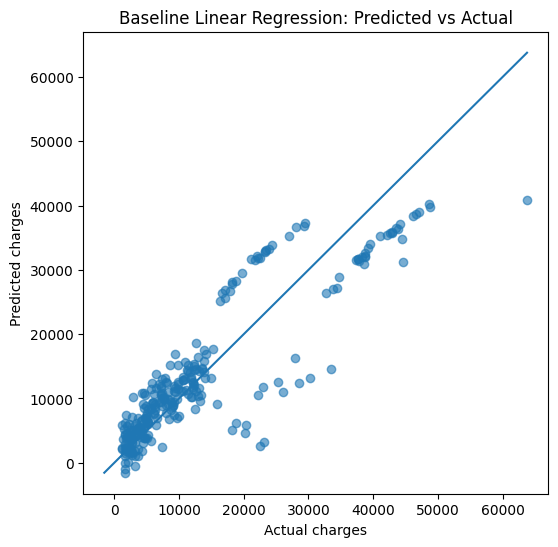

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_base, alpha=0.6)
plt.title("Baseline Linear Regression: Predicted vs Actual")
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")

minv = min(y_test.min(), pred_base.min())
maxv = max(y_test.max(), pred_base.max())
plt.plot([minv, maxv], [minv, maxv])
plt.show()


## Part 2
## Summary of findings

This analysis began with a baseline linear regression model using the same preprocessing approach as in EX5, where categorical variables were dummy coded and numeric variables were scaled. This baseline model performed well and provided a strong reference point for evaluating more advanced techniques.

Polynomial features were then added to the numeric variables (age, bmi, and children) in order to capture possible non linear relationships. However, polynomial models with degree 2 and degree 3 did not improve predictive performance. Instead, they slightly increased the test error, indicating that the added complexity did not generalize well to unseen data.

Regularization methods, including Ridge, Lasso, and Elastic Net, were also applied using cross validation to select optimal hyperparameters. These models produced results similar to or slightly worse than the baseline model. Ridge regression performed closest to the baseline, while Lasso and Elastic Net showed reduced accuracy due to stronger coefficient shrinkage.

Overall, the baseline linear regression model remained the best performing model. It achieved the lowest prediction error while maintaining simplicity and interpretability, demonstrating that more complex models are not always necessary when the underlying relationships in the data are largely linear.